In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Cleaning & Preprocessing

In [2]:
df = pd.read_csv("books_raw.csv")
df.head()

,title,price,rating,availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         1000 non-null   object
 1   price         1000 non-null   object
 2   rating        1000 non-null   object
 3   availability  1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB


In [4]:
df.isnull().sum()

title           0
price           0
rating          0
availability    0
dtype: int64

In [5]:
df["price"] = df["price"].str.replace("Â£","", regex=False)  # convert price col object to float
df["price"] = df["price"].astype(float)

In [6]:
rating_map = {
    "One" : 1,
    "Two" : 2,
    "Three" : 3,
    "Four" : 4,
    "Five" : 5
}
df["rating"] = df["rating"].map(rating_map)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1000 non-null   object 
 1   price         1000 non-null   float64
 2   rating        1000 non-null   int64  
 3   availability  1000 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


In [8]:
df["availability"] = df["availability"].str.strip() # removes extra spaces 

In [9]:
df.rename(columns = {
    "title" : "Title",
    "price" : "Price",
    "rating" : "Rating",
    "availability" : "Availability"},inplace = True)

In [10]:
df.columns

Index(['Title', 'Price', 'Rating', 'Availability'], dtype='object')

In [11]:
df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock


In [12]:
df.to_csv("books_cleaned.csv", index=False)

### Exploratory Data Analysis & Visualization

In [13]:
df["Price"].mean()

35.07035

In [14]:
df["Price"].median()

35.980000000000004

In [15]:
df["Price"].describe()

count    1000.00000
mean       35.07035
std        14.44669
min        10.00000
25%        22.10750
50%        35.98000
75%        47.45750
max        59.99000
Name: Price, dtype: float64

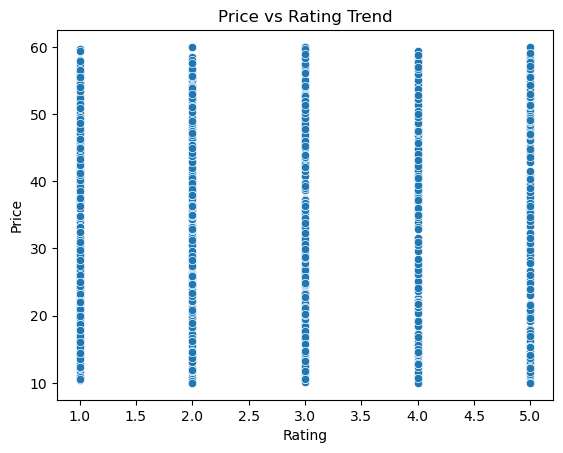

In [16]:
sns.scatterplot(x = "Rating",y = "Price",data = df)
plt.title("Price vs Rating Trend")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.show()

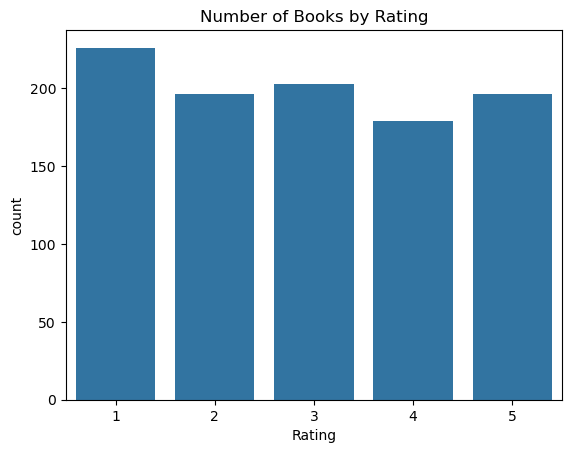

In [17]:
sns.countplot(x="Rating", data=df)

plt.title("Number of Books by Rating")
plt.show()

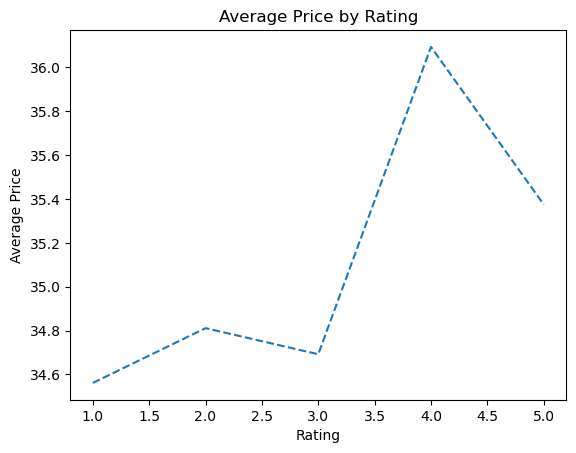

In [18]:
avg_price = df.groupby("Rating")["Price"].mean()

avg_price.plot(kind="line", linestyle = "--")

plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.show()

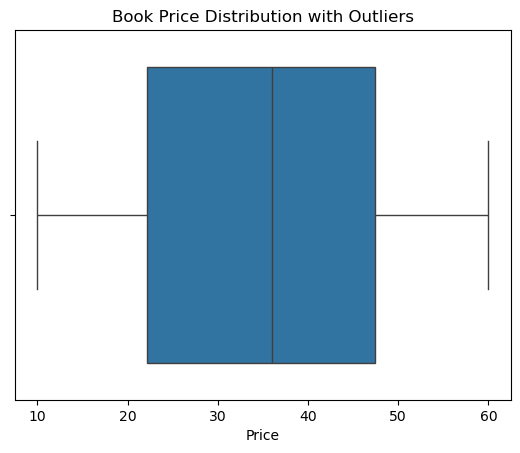

In [19]:
sns.boxplot(x=df["Price"])

plt.title("Book Price Distribution with Outliers")
plt.show()

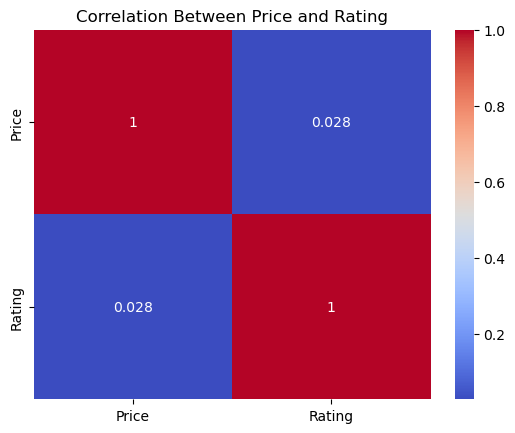

In [20]:
corr = df[["Price","Rating"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Price and Rating")
plt.show()

### Model Building & Evaluation

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [44]:
x = df[["Rating"]]
y = df["Price"]

In [45]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 1)
(200, 1)
(800,)
(200,)


In [46]:
model1 = LinearRegression() # creates Linear Regression model object.

In [47]:
model1.fit(x_train,y_train) # This trains the model using the training dataset

LinearRegression()

In [48]:
y_pred = model1.predict(x_test)

In [49]:
y_pred

array([36.03478658, 34.59455066, 35.31466862, 36.03478658, 35.31466862,
       34.59455066, 34.59455066, 34.95460964, 34.95460964, 34.59455066,
       34.95460964, 35.31466862, 36.03478658, 36.03478658, 35.31466862,
       34.59455066, 34.59455066, 36.03478658, 34.59455066, 35.31466862,
       35.6747276 , 36.03478658, 34.59455066, 36.03478658, 35.6747276 ,
       35.6747276 , 34.95460964, 35.6747276 , 35.6747276 , 34.59455066,
       34.95460964, 35.6747276 , 36.03478658, 35.6747276 , 35.6747276 ,
       35.31466862, 35.31466862, 35.6747276 , 35.6747276 , 35.31466862,
       35.31466862, 34.59455066, 34.95460964, 35.6747276 , 35.31466862,
       36.03478658, 35.6747276 , 36.03478658, 34.59455066, 36.03478658,
       34.95460964, 34.59455066, 36.03478658, 35.31466862, 36.03478658,
       36.03478658, 35.31466862, 34.95460964, 34.95460964, 34.59455066,
       35.6747276 , 36.03478658, 34.95460964, 34.95460964, 35.31466862,
       34.59455066, 36.03478658, 35.31466862, 35.31466862, 36.03

In [50]:
print("MSE:", mean_squared_error(y_test,y_pred))
print("R2_Score:", r2_score(y_test,y_pred))
      

MSE: 211.4538481028864
R2_Score: -0.006618384017733847


In [51]:
from sklearn.tree import DecisionTreeRegressor

In [52]:
tree_model = DecisionTreeRegressor(random_state = 42)

In [53]:
tree_model.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [57]:
y_pred_tree = tree_model.predict(x_test) # The trained model predicts book prices for the testing data.
y_pred_tree

array([36.25230263, 34.47521505, 35.18453416, 36.25230263, 35.18453416,
       34.47521505, 34.47521505, 35.33626582, 35.33626582, 34.47521505,
       35.33626582, 35.18453416, 36.25230263, 36.25230263, 35.18453416,
       34.47521505, 34.47521505, 36.25230263, 34.47521505, 35.18453416,
       35.32356643, 36.25230263, 34.47521505, 36.25230263, 35.32356643,
       35.32356643, 35.33626582, 35.32356643, 35.32356643, 34.47521505,
       35.33626582, 35.32356643, 36.25230263, 35.32356643, 35.32356643,
       35.18453416, 35.18453416, 35.32356643, 35.32356643, 35.18453416,
       35.18453416, 34.47521505, 35.33626582, 35.32356643, 35.18453416,
       36.25230263, 35.32356643, 36.25230263, 34.47521505, 36.25230263,
       35.33626582, 34.47521505, 36.25230263, 35.18453416, 36.25230263,
       36.25230263, 35.18453416, 35.33626582, 35.33626582, 34.47521505,
       35.32356643, 36.25230263, 35.33626582, 35.33626582, 35.18453416,
       34.47521505, 36.25230263, 35.18453416, 35.18453416, 36.25

In [58]:
print("MSE:", mean_squared_error(y_test,y_pred_tree))
print("R2_Score:",r2_score(y_test,y_pred_tree))

MSE: 212.53130086154238
R2_Score: -0.011747558844791062


In [59]:
from sklearn.ensemble import RandomForestRegressor

In [60]:
rf_model = RandomForestRegressor(random_state = 42)

In [61]:
rf_model.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [63]:
y_pred_rf = rf_model.predict(x_test)

In [64]:
print("MSE:",mean_squared_error(y_test,y_pred_rf))
print("R2_Score:",r2_score(y_test,y_pred_rf))

MSE: 212.80942187445763
R2_Score: -0.013071543851892686


### Video Explanation

#### https://www.loom.com/share/97bdb96e561147918e7f52ec650c1823